In [2]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

In [4]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# visualize the data


# remove outliers

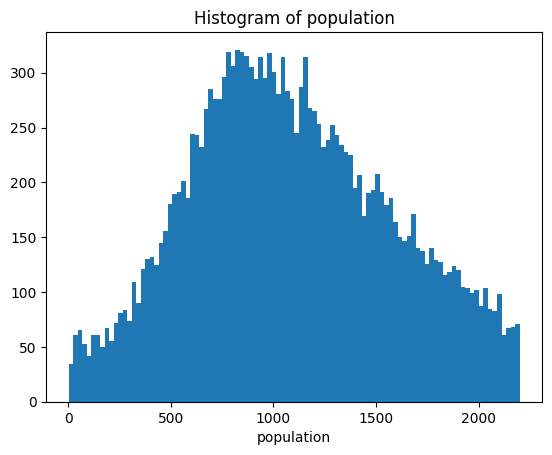

In [8]:
housing = housing[housing["population"] <= 2200]

plt.hist(housing["population"], bins=100)
plt.xlabel("population")
plt.title("Histogram of population")
plt.show()

# Predicting House Mean range (linear regression 1 var)

Mean Absolute Error: 91183.19294483737
Mean Squared Error: 13166016668.514061
Root Mean Squared Error: 114743.26415312605


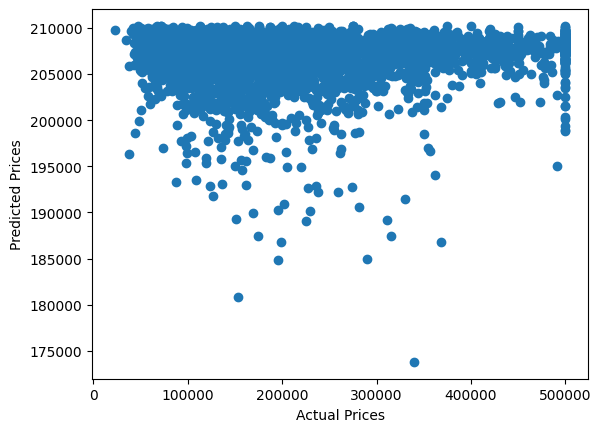

R-squared: 0.000743198210971685


In [6]:
# Assuming 'median_house_value' is the target and the rest are the features
# X = housing.drop('median_house_value', axis=1)
# X = housing["population"].values.reshape(-1, 1)
X = housing["population"]
y = housing['median_house_value']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Convert X_train and X_test to a 2D array
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

# Create an instance of the LR model
regressor = LinearRegression()

# Fit the model to the training data
regressor.fit(X_train, y_train)

# Predict the output for the test data
y_pred = regressor.predict(X_test)

# Evaluate the model
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred)) #i have no idea what these numbers mean rn
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred)) #i have no idea what these numbers mean rn
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred))) #i have no idea what these numbers mean rn

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show() # multiple regressin t7t worked better for some reason

r2 = metrics.r2_score(y_test, y_pred)
print("R-squared:", r2) # very bad score...

# Predicting House Mean range (linear regression many vars)

Mean Absolute Error: 50760.899897486044
Mean Squared Error: 4719497692.609217
Root Mean Squared Error: 68698.60036863355


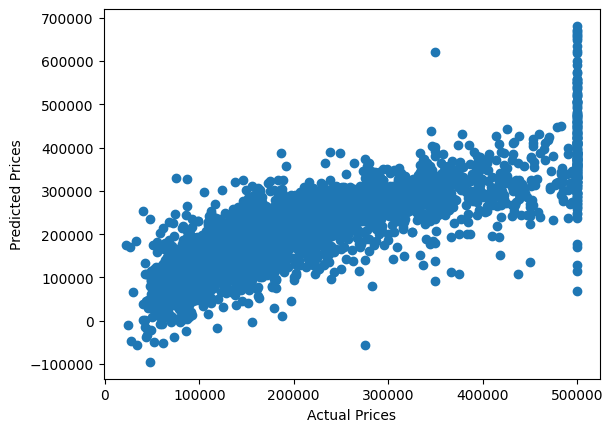

R-squared: 0.6708592815999237


In [7]:
#non categorical data
housing.loc[:, 'ocean_proximity'] = housing['ocean_proximity'].astype('category').cat.codes

# check if any columns have missing values
# print(housing.isnull().sum())

#replace na with mean
housing.loc[:, 'total_bedrooms'] = housing['total_bedrooms'].fillna(housing['total_bedrooms'].mean())
# print(housing.isnull().sum())

housing = housing[housing["population"] <= 2200]

X = housing.drop('median_house_value', axis=1)
y = housing['median_house_value']

# print(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# LinearRegression
regressor = LinearRegression()

# fitting
regressor.fit(X_train, y_train)

# predicting
y_pred = regressor.predict(X_test)

# coefficients
# print(regressor.coef_)

# evaluating
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()

r2 = metrics.r2_score(y_test, y_pred)
print("R-squared:", r2)